In [1]:
# Import các thư viện
import pandas as pd
import numpy as np
import time
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
from google.colab import data_table
data_table.enable_dataframe_formatter()

ĐƯỜNG LINK TẢI DATASET: https://huggingface.co/datasets/AzharAli05/Resume-Screening-Dataset

I. DATA CLEANING  


1. SƠ BỘ DỮ LIỆU

In [2]:
#Kiểm tra encoding
df = pd.read_csv('dataset.csv', encoding = 'utf-8', engine='python', on_bad_lines='skip')
df.head()

#Xem cấu trúc cơ bản
print('CẤU TRÚC CƠ BẢN: ')
df.info()

  #Số dòng và cột
print('SỐ LƯỢNG DÒNG VÀ CỘT: ')
print(df.shape)

  #Kiểu dữ liệu của các cột
print('KIỂU DỮ LIỆU CỦA CÁC CỘT: ')
print(df.dtypes)

CẤU TRÚC CƠ BẢN: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Role                 10174 non-null  object
 1   Resume               10174 non-null  object
 2   Decision             10174 non-null  object
 3   Reason_for_decision  10174 non-null  object
 4   Job_Description      10174 non-null  object
dtypes: object(5)
memory usage: 397.6+ KB
SỐ LƯỢNG DÒNG VÀ CỘT: 
(10174, 5)
KIỂU DỮ LIỆU CỦA CÁC CỘT: 
Role                   object
Resume                 object
Decision               object
Reason_for_decision    object
Job_Description        object
dtype: object


2. KIỂM TRA MISSING VALUES, DUPLICATES, OUTLIERS

In [3]:
# Kiểm tra dữ liệu thiếu (Missing Values)
missing_values = df.isnull().sum()
print("Đếm dữ liệu thiếu:\n", missing_values)

  #Xóa các dòng thiếu ở các cột (nếu có vấn đề)
col_drop = df.dropna()

  #Kiểm tra có cột nào chứa khoảng trắng không
empty_values = df.apply(lambda x: x.str.strip().eq('').any())
print("Cột chứa khoảng trắng: \n", empty_values)

# Kiểm tra độ trùng lặp (Duplicates)
duplicates = df.duplicated().sum()
print("Độ trùng lặp dữ liệu: \n", duplicates)

  #Chỉ giữ lại bản ghi đầu tiên (nếu có vấn đề)
df = df.drop_duplicates(subset=['Resume'], keep='first')

# Mâu thuẫn logic: Xác định các RESUME giống nội dung khác nhau về DECISION
conflicts = df.groupby('Resume').filter(lambda x: len(x['Decision'].unique()) > 1)
print("Các RESUME giống nội dung khác nhau về DECISION: \n", conflicts)

# Kiểm tra unique
unique_values = df.nunique()
print("Số lượng unique: \n", unique_values)

#Kiểm tra lại số lượng dòng và cột
print(f'Số lượng dòng: {col_drop.shape[0]}')
print(f'Số lượng cột: {col_drop.shape[1]}')

Đếm dữ liệu thiếu:
 Role                   0
Resume                 0
Decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64
Cột chứa khoảng trắng: 
 Role                   False
Resume                 False
Decision               False
Reason_for_decision    False
Job_Description        False
dtype: bool
Độ trùng lặp dữ liệu: 
 0
Các RESUME giống nội dung khác nhau về DECISION: 
 Empty DataFrame
Columns: [Role, Resume, Decision, Reason_for_decision, Job_Description]
Index: []
Số lượng unique: 
 Role                      45
Resume                 10174
Decision                   2
Reason_for_decision      539
Job_Description         3446
dtype: int64
Số lượng dòng: 10174
Số lượng cột: 5


3. CHUẨN HÓA DỮ LIỆU

In [4]:
# Chuẩn hóa dữ liệu
# Chuẩn hóa text đưa về chữ thường nhưng giữ nguyên NaN
for col in col_drop.select_dtypes(include=['object']).columns:
    col_drop[col] = col_drop[col].str.strip().str.lower()


# Chuẩn hóa thuộc tính 'Role'
# Đưa Role về dạng Title Case
col_drop['Role'] = col_drop['Role'].str.title()

# Chuẩn hóa các từ viết tắt
abbreviation_map = {
    'Ui': 'UI',
    'Ux': 'UX',
    'Qa': 'QA',
    'Ai': 'AI',
    'Hr': 'HR',
    'Ar': 'AR',
    'Vr': 'VR'
}

for short, full in abbreviation_map.items():
    col_drop['Role'] = col_drop['Role'].str.replace(
        rf'\b{short}\b', full, regex=True
    )

# Gộp các Role trùng nghĩa
role_map = {
    'UI Designer': 'UI/UX Designer',
    'UX Designer': 'UI/UX Designer',
    'UI/UX Designer': 'UI/UX Designer',
    'AI Engineer': 'AI Researcher/Engineer',
    'AI Researcher': 'AI Researcher/Engineer'
}

col_drop['Role'] = col_drop['Role'].replace(role_map)

# Kiểm tra sau chuẩn hóa

print("Số lượng giá trị unique sau khi chuẩn hóa:")
print(col_drop.nunique())

# Xem dữ liệu
col_drop.head()


Số lượng giá trị unique sau khi chuẩn hóa:
Role                      35
Resume                 10174
Decision                   2
Reason_for_decision      539
Job_Description         3446
dtype: int64


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-Commerce Specialist,here's a professional resume for jason jones:\...,reject,lacked leadership skills for a senior position.,be part of a passionate team at the forefront ...
1,Game Developer,here's a professional resume for ann marshall:...,select,strong technical skills in ai and ml.,help us build the next-generation products as ...
2,Human Resources Specialist,here's a professional resume for patrick mccla...,reject,insufficient system design expertise for senio...,we need a human resources specialist to enhanc...
3,E-Commerce Specialist,here's a professional resume for patricia gray...,select,impressive leadership and communication abilit...,be part of a passionate team at the forefront ...
4,E-Commerce Specialist,here's a professional resume for amanda gross:...,reject,lacked leadership skills for a senior position.,we are looking for an experienced e-commerce s...


3.4. XỬ LÝ CỘT RESUME

In [5]:
#Bộ từ dừng
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

resume_stopwords = {
    # Thông tin liên hệ
    'contact', 'email', 'phone', 'linkedin', 'github', 'website', 'address',

    # Cấu trúc CV
    'resume', 'cv', 'summary', 'professional', 'experience', 'education',
    'skills', 'skill', 'certifications', 'certification', 'certified',
    'references', 'available', 'upon', 'request', 'objective',

    # Học vấn
    'bachelor', 'master', 'degree', 'university', 'college', 'graduated',

    # Từ chung chung trong mọi CV
    'team', 'cross', 'functional', 'proven', 'track', 'record',
    'results', 'driven', 'highly', 'motivated', 'strong', 'excellent',
    'high', 'quality', 'best', 'practice', 'practices',

    # Động từ phổ biến
    'developed', 'implemented', 'managed', 'created', 'designed',
    'collaborated', 'worked', 'resulting', 'increase', 'increased',
    'delivered', 'delivering', 'maintained', 'developed', 'using',

    # Placeholder và tên công ty mẫu
    'xyz', 'abc', 'corporation', 'company', 'inc', 'llc', 'sample',
    'name', 'present', 'current', 'information',

    # Thời gian
    'years', 'year', 'months', 'month', 'present', 'current'
}

# Gộp tất cả stopwords
stop_words.update(resume_stopwords)

def clean_text(text, role_name=None):
    if pd.isna(text):
        return text

    # Chuyển về lowercase
    text = text.lower()

    # Loại bỏ thông tin về role trong Resume
    if role_name:
        role_lower = str(role_name).lower().strip()
        # Thay thế tên Role bằng khoảng trắng
        text = text.replace(role_lower, ' ')

    #Xử lý dấu xuống dòng, thay thế bằng dấu cách
    text = text.replace('\r\n', ' ').replace('\r', ' ').replace('\n', ' ')

    #Xử lý khoảng trắng
    text = text.replace('\t', ' ').replace('\f', ' ').replace('\v', ' ')

    #Xóa thông tin nhiễu
    text = re.sub(r'\S*@\S*\s?', ' ', text) # Xóa Email
    text = re.sub(r'\d{10,12}', ' ', text) # Xóa số điện thoại
    text = re.sub(r'http\S+|www\S+', ' ', text) # Xóa Link
    text = re.sub(r'linkedin\. com\S*', ' ', text) # Xóa URL LinkedIn

    # Xóa phần trăm và số
    text = re.sub(r'\d+%', ' ', text)
    text = re.sub(r'\d+\+? ', ' ', text)

    # Xóa thông tin về năm (2015, 2028-present,...)
    text = re.sub(r'\b(19|20)\d{2}\b', ' ', text)
    text = re.sub(r'\b\d{4}\s*-\s*(present|\d{4})\b', ' ', text, flags=re.IGNORECASE)

    extra_stopwords = {'contact', 'email', 'phone', 'linked', 'github'}
    stop_words.update(extra_stopwords) #xóa từ đi kèm thông tin nhiễu

    #Xóa ký tự đặc biệt
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)


    #Xóa stopwords và khoảng trắng thừa
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    text = ' '.join(words)

    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

col_drop['Resume_Cleaned'] = col_drop.apply(lambda row: clean_text(row['Resume'], row['Role']), axis=1)
col_drop['Resume_Cleaned']

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Resume_Cleaned
0,jason jones jason jones com jasonjones invento...
1,ann marshall ann marshall com annmarshall com ...
2,patrick mcclain patrick mcclain com patrickmcc...
3,patricia gray patricia gray com patriciagray d...
4,amanda gross amanda gross com amandagross comm...
...,...
10169,diana miller diana miller com dianamiller driv...
10170,grace taylor grace taylor com gtaylor leverage...
10171,hank brown hank brown com hankbrownui com hank...
10172,diana wilson diana wilson main anytown usa com...


3.5.1. ENCODING

In [6]:
# Kiểm tra tính logic giữa Decision và Reason_for_decision
def logic_check(row):
  reason_for_decision = str(row['Reason_for_decision'])
  decision = str(row['Decision'])

  # Nếu reject nhưng lý do chứa từ khen ngợi và ngược lại
  if decision == 'reject' and any(kw in reason_for_decision for kw in ['Strong', 'Impressive','Excellent','Solid','Perfectly']):
    return False
  return True

# Loại bỏ dữ liệu mâu thuẫn logic
  col_drop = col_drop[col_drop.apply(logic_check, axis=1)]
  col_drop = col_drop[col_drop['is_consistent'] == True].drop(columns=['is_consistent'])


In [7]:
# Mã hóa dữ liệu
#khởi tạo
le_role = LabelEncoder()
le_decision = LabelEncoder()

# Mã hóa
col_drop['Role_Encoded'] = le_role.fit_transform(col_drop['Role'])
col_drop['Decision_Encoded'] = le_decision.fit_transform(col_drop['Decision'])

# Xuất file encoding
dataset_encoding = col_drop[['Role_Encoded', 'Decision_Encoded']]
dataset_encoding.to_csv('dataset_encoding.csv', index=False)
dataset_encoding.head()

# Xuất file sạch
dataset_clean = col_drop[['Role','Resume_Cleaned', 'Decision','Reason_for_decision','Job_Description', 'Role_Encoded']]
dataset_clean.to_csv('dataset_clean.csv', index=False)
dataset_clean.head()

,Role,Resume_Cleaned,Decision,Reason_for_decision,Job_Description,Role_Encoded
0,E-Commerce Specialist,jason jones jason jones com jasonjones invento...,reject,lacked leadership skills for a senior position.,be part of a passionate team at the forefront ...,16
1,Game Developer,ann marshall ann marshall com annmarshall com ...,select,strong technical skills in ai and ml.,help us build the next-generation products as ...,18
2,Human Resources Specialist,patrick mcclain patrick mcclain com patrickmcc...,reject,insufficient system design expertise for senio...,we need a human resources specialist to enhanc...,21
3,E-Commerce Specialist,patricia gray patricia gray com patriciagray d...,select,impressive leadership and communication abilit...,be part of a passionate team at the forefront ...,16
4,E-Commerce Specialist,amanda gross amanda gross com amandagross comm...,reject,lacked leadership skills for a senior position.,we are looking for an experienced e-commerce s...,16


II. EDA  

1. Phân bố ngành nghề (Role): Biểu đồ cột xem ngành nào nhiều hồ sơ nhất

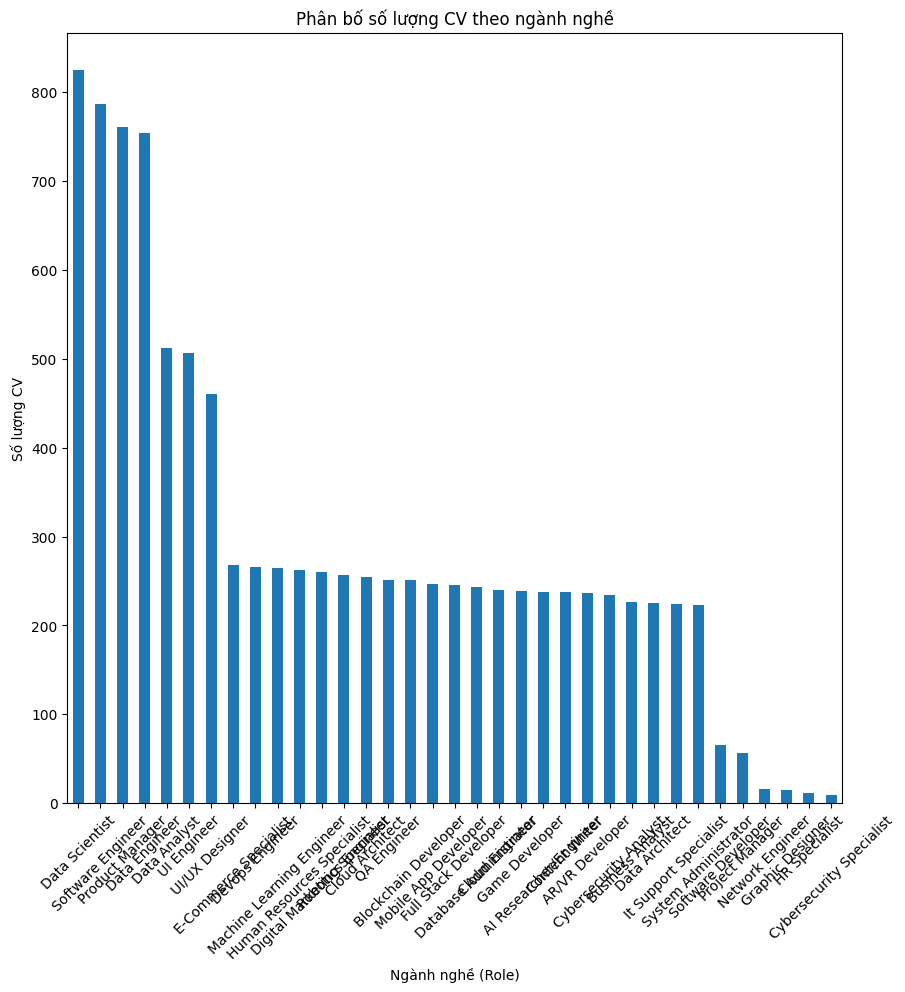

,count
Role,
Data Scientist,825
Software Engineer,787
Product Manager,761
Data Engineer,754
Data Analyst,512
UI Engineer,507
UI/UX Designer,460
E-Commerce Specialist,268
Devops Engineer,266


In [24]:

role_counts = dataset_clean['Role'].value_counts()

plt.figure(figsize=(10,10))
role_counts.plot(kind='bar')
plt.title('Phân bố số lượng CV theo ngành nghề')
plt.xlabel('Ngành nghề (Role)')
plt.ylabel('Số lượng CV')
plt.xticks(rotation=45)
plt.show()

dataset_clean['Role'].value_counts()

Nhận xét: Dataset không phân bố đều giữa các ngành. Một số ngành như Data Scientist, Software Engineer,... có số lượng CV cao trong khi những ngành như HR Specialist, Cybersecurity Specialist lại có số lượng CV thấp hơn đáng kể

2. Phân tích tuyển dụng (Decision): Tỷ lệ Select vs Reject

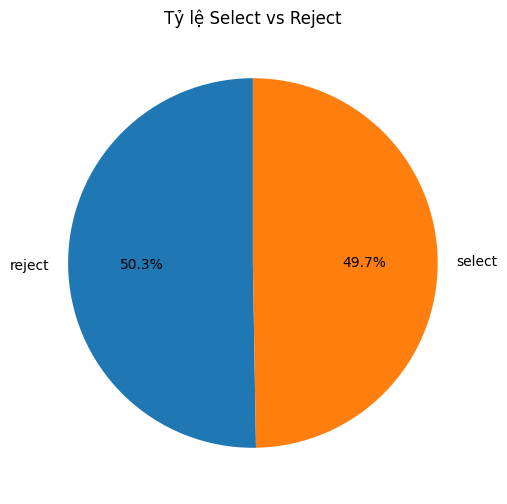

In [9]:
decision_counts = dataset_clean['Decision'].value_counts()

plt.figure(figsize=(6,6))
decision_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Tỷ lệ Select vs Reject')
plt.ylabel('')
plt.show()


Nhận xét: Tỷ lệ gần cân bằng. Biến mục tiêu của mô hình là Role, không phải Decision

=> Dataset mang tính tuyển chọn khắt khe, không phải ngẫu nhiên



### 3. WordCloud:

3a. Cloud 1: Từ khóa phổ biến trong resume

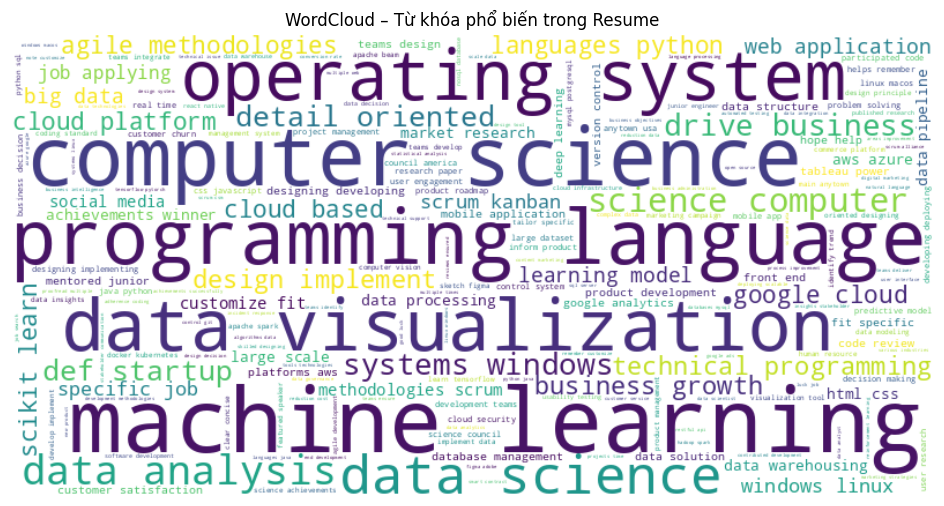

In [10]:
text_resume = " ".join(dataset_clean['Resume_Cleaned'])

wc_resume = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_resume)

plt.figure(figsize=(12,6))
plt.imshow(wc_resume, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud – Từ khóa phổ biến trong Resume')
plt.show()


Nhận xét: Thông qua WordCloud, ta có thể phân loại các từ phổ biến này thành 2 nhóm:


1.   Kỹ thuật/ chuyên môn: machine learning, data scientist, data engineer, programming language, technical skill, data analysist, data visualization,... => Dataset có tỷ lệ lớn CV thuộc khối kỹ thuật
2.   Mô tả kỹ năng mềm/ cách làm việc: team, cross functional, collaborated, highly motivated,... => Những từ này xuất hiện ở mọi ngành, có giá trị thấp trong việc phân loại CV theo ngành nghề





3b. Cloud 2 (Insight): Từ khóa phổ biến trong cột reason for decision của những người bị loại (Decision == Reject). -> Trả lời: Tại sao rớt?

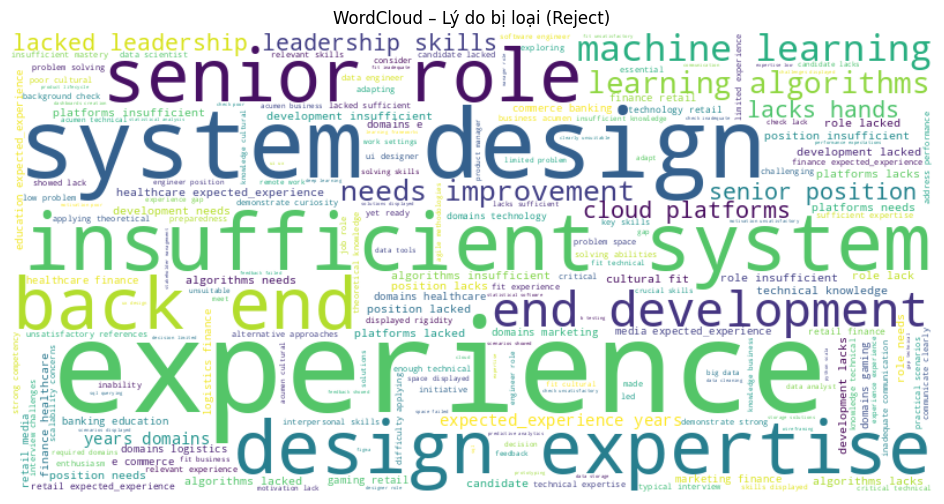

Reason_for_decision
insufficient system design expertise for senior role.    0.143
no experience in back-end development.                   0.140
needs improvement in machine learning algorithms.        0.138
lacked leadership skills for a senior position.          0.134
lacks hands-on experience with cloud platforms.          0.130
technical knowledge                                      0.021
cultural fit                                             0.018
experience                                               0.014
business acumen                                          0.013
lack of relevant skills or experience.                   0.012
Name: proportion, dtype: float64


In [23]:
reject_reasons = dataset_clean.loc[dataset_clean['Decision'] == 'reject', 'Reason_for_decision']
text_reject = " ".join(reject_reasons.dropna())

wc_reject = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_reject)

plt.figure(figsize=(12,6))
plt.imshow(wc_reject, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud – Lý do bị loại (Reject)')
plt.show()

print(reject_reasons.value_counts(normalize=True).head(10).round(3))

Nhận xét: Lý do bị loại tập trung chủ yếu vào năng lực và mức độ phù hợp, không phải yếu tố hình thức.
Phân nhóm nguyên nhân bị loại:


1.   Thiếu kinh nghiệm (nguyên nhân chính): expected experience, years, senior role, insufficient,...

*   Ứng viên không đạt mức kinh nghiệm yêu cầu cho vị trí

*   Đặc biệt: Ứng tuyển vị trí senior nhưng kinh nghiệm chỉ ở mức junior / mid

=> Insight 1: Phần lớn CV bị loại vì không phù hợp kinh nghiệm, chứ không phải thiếu nền tảng hoàn toàn.

2.   Thiếu kỹ năng chuyên môn cụ thể: system design, backend, machine learning, learning algorithms, technical knowledge, ....


*   Ứng viên có nền tảng chung nhưng thiếu kỹ năng cốt lõi cho vị trí cụ thể
*   Chẳng hạn như backend nhưng thiếu system design, data/ machine learning nhưng yếu algorithms

=> Insight 2: Nhà tuyển dụng đánh giá rất cao về kỹ thuật chuyên môn, không chỉ danh sách kỹ năng chung.


3.   Thiếu kỹ năng bổ trợ / kỹ năng mềm: leadership skills, culture fit, communication, role needs, ...



=> Insight 3: Bất cứ ngành nghề hay ở vị trí nào thì kỹ năng mềm/ thích ứng văn hóa luôn là điều kiện cần









4. Độ dài CV: So sánh độ dài CV giữa các ngành

In [26]:
# Thống kê mô tả Resume_Length theo Role
dataset_clean['Resume_Length'] = dataset_clean['Resume_Cleaned'].apply(lambda x: len(str(x)))
dataset_clean.groupby("Role")["Resume_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Role,,,,,,,,
AI Researcher/Engineer,238.0,1909.684874,239.451583,1103.0,1746.00,1915.5,2063.25,2567.0
AR/VR Developer,237.0,1104.067511,612.635702,67.0,549.00,1368.0,1595.00,2235.0
Blockchain Developer,251.0,1791.390438,168.905083,1282.0,1682.00,1772.0,1889.00,2420.0
Business Analyst,226.0,1656.287611,187.361544,1197.0,1516.75,1653.0,1770.25,2190.0
Cloud Architect,254.0,1753.062992,181.722272,1162.0,1635.50,1748.5,1875.50,2219.0
Cloud Engineer,240.0,1733.504167,182.903569,884.0,1618.00,1720.0,1837.75,2451.0
Content Writer,238.0,1700.983193,222.271776,1107.0,1546.75,1704.0,1839.75,2504.0
Cybersecurity Analyst,234.0,1894.735043,183.382075,1331.0,1776.00,1881.5,1993.75,2914.0
Cybersecurity Specialist,9.0,1589.222222,191.512257,1287.0,1419.00,1662.0,1698.00,1819.0


In [13]:
# Phân tích Q1-Median-Q3-IQR
stats = dataset_clean.groupby("Role")["Resume_Length"].agg(
    Q1=lambda x: x.quantile(0.25),
    Median=lambda x: x.quantile(0.5),
    Q3=lambda x: x.quantile(0.75)
)

stats["IQR"] = stats["Q3"] - stats["Q1"]
stats = stats.sort_values("Median", ascending=False)
stats

,Q1,Median,Q3,IQR
Role,,,,
AI Researcher/Engineer,1746.00,1915.5,2063.25,317.25
Cybersecurity Analyst,1776.00,1881.5,1993.75,217.75
Machine Learning Engineer,1733.00,1853.0,1990.00,257.00
Project Manager,1615.50,1853.0,2070.75,455.25
Human Resources Specialist,1720.75,1838.0,1972.75,252.00
Data Scientist,1685.00,1826.0,2062.00,377.00
UI/UX Designer,1571.75,1779.0,2056.50,484.75
Blockchain Developer,1682.00,1772.0,1889.00,207.00
Database Administrator,1648.50,1770.0,1891.00,242.50


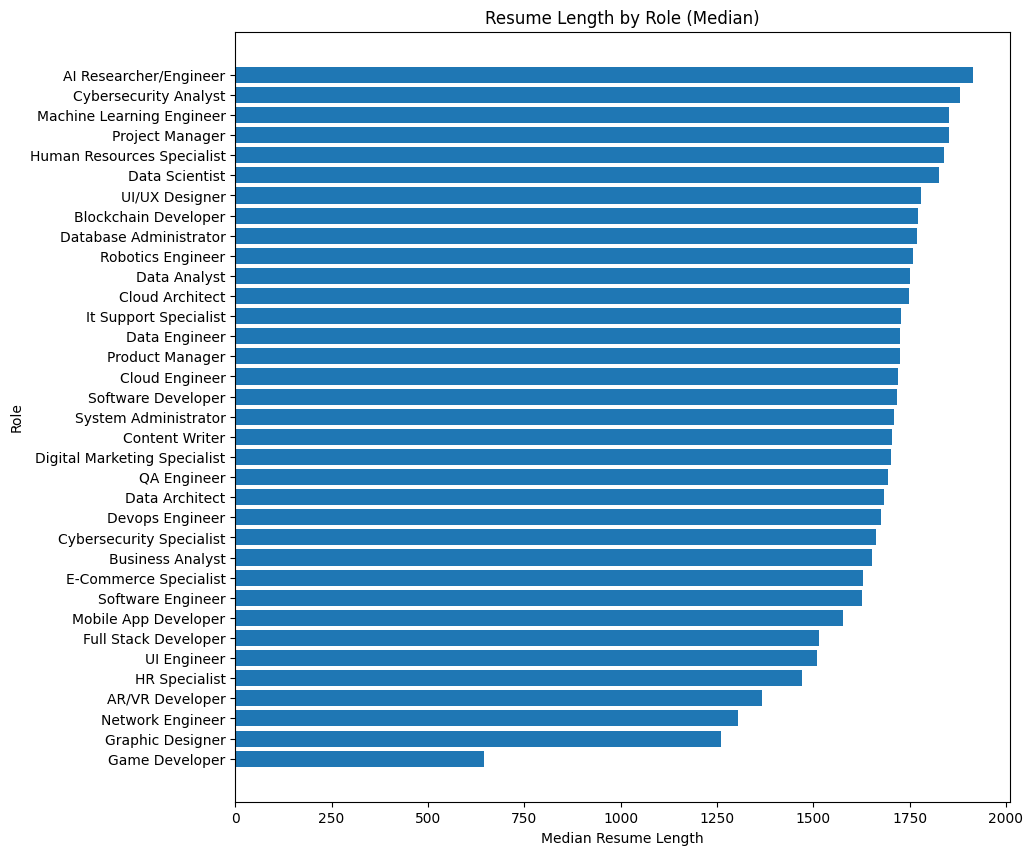

In [14]:
# Biểu đồ Median Resume_Length theo Role
plt.figure(figsize=(10,10))
plt.barh(stats.index, stats['Median'])
plt.xlabel('Median Resume Length')
plt.ylabel('Role')
plt.title('Resume Length by Role (Median)')
plt.gca().invert_yaxis()
plt.show()


III. TRAIN BASELINE MODEL (KNN VÀ NAIVE BAYES)    

In [15]:
# Encode Target: Role -> Role_Encoded
print("Sample data sau khi xử lý:")
print(dataset_clean[['Resume_Cleaned', 'Role_Encoded']].head())

# Input và Target
X_text = dataset_clean['Resume_Cleaned']
y = dataset_clean['Role_Encoded']

# Split train/test for text data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=dataset_clean['Role_Encoded'])
print(f"\nTrain size: {X_train_text.shape[0]}, Test size: {X_test_text.shape[0]}")

# TF-IDF for KNN/Naive Bayes
tfidf = TfidfVectorizer(ngram_range=(1, 1), max_features=2000)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

# KNN với các giá trị k khác nhau - tìm best k
k_values = [3, 5, 7, 9, 11, 15] # Thử k=5 và các giá trị khác
best_k = 5
best_acc_knn = 0
best_time_knn = 0

print(f"\n{'K':<5} | {'Accuracy':<10} | {'Time (s)':<10}")
for k in k_values:
    start_time = time.time()

    # Train
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict
    y_pred_knn = knn.predict(X_test)

    end_time = time.time()
    run_time = end_time - start_time
    acc = accuracy_score(y_test, y_pred_knn)

    print(f"{k:<5} | {acc:.4f}     | {run_time:.4f}")

    # Lưu lại model tốt nhất
    if acc > best_acc_knn:
        best_acc_knn = acc
        best_k = k
        best_time_knn = run_time

print(f"\n=> Best KNN: k={best_k} với Accuracy={best_acc_knn:.4f}")

# Naive Bayes
start_time_nb = time.time()

# Train
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict
y_pred_nb = nb.predict(X_test)

end_time_nb = time.time()
time_nb = end_time_nb - start_time_nb
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"\nNaive Bayes\n Accuracy: {acc_nb:.4f}")
print(f" Time: {time_nb:.4f} s")

# Tổng kết và nhận xét
print("\nTỔNG KẾT VÀ NHẬN XÉT")
print(f"1. KNN (Best k={best_k}): Accuracy = {best_acc_knn:.2%}, Time = {best_time_knn:.4f}s")
print(f"2. Naive Bayes:     Accuracy = {acc_nb:.2%}, Time = {time_nb:.4f}s")

if time_nb < best_time_knn:
    print(f"- Mô hình Naive Bayes chạy NHANH HƠN KNN gấp {best_time_knn/time_nb:.1f} lần.")
elif time_nb > best_time_knn:
    print(f"- Mô hình KNN chạy NHANH HƠN Naive Bayes gấp {time_nb/best_time_knn:.1f} lần.")
else:
    print("- Hai mô hình có thời gian chạy tương đương nhau.")

if acc_nb > best_acc_knn:
    print("- Về độ chính xác: Naive Bayes tốt hơn.")
elif acc_nb < best_acc_knn:
    print("- Về độ chính xác: KNN tốt hơn.")
else:
    print("- Hai mô hình có độ chính xác tương đương.")

Sample data sau khi xử lý:
                                      Resume_Cleaned  Role_Encoded
0  jason jones jason jones com jasonjones invento...            16
1  ann marshall ann marshall com annmarshall com ...            18
2  patrick mcclain patrick mcclain com patrickmcc...            21
3  patricia gray patricia gray com patriciagray d...            16
4  amanda gross amanda gross com amandagross comm...            16

Train size: 8139, Test size: 2035

K     | Accuracy   | Time (s)  
3     | 0.9725     | 1.6948
5     | 0.9646     | 1.6940
7     | 0.9651     | 1.6903
9     | 0.9705     | 1.6723
11    | 0.9799     | 1.7322
15    | 0.9867     | 1.9093

=> Best KNN: k=15 với Accuracy=0.9867

Naive Bayes
 Accuracy: 0.9690
 Time: 0.0453 s

TỔNG KẾT VÀ NHẬN XÉT
1. KNN (Best k=15): Accuracy = 98.67%, Time = 1.9093s
2. Naive Bayes:     Accuracy = 96.90%, Time = 0.0453s
- Mô hình Naive Bayes chạy NHANH HƠN KNN gấp 42.1 lần.
- Về độ chính xác: KNN tốt hơn.


IV. TRAIN SVM và Apriori    

In [16]:
# Feature extraction
tfidf_svm = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

X_train_svm = tfidf_svm.fit_transform(X_train_text)
X_test_svm = tfidf_svm.transform(X_test_text)

# Tuning LinearSVC
param_grid = {'C': [0.1, 1, 10, 100]}
grid = GridSearchCV(LinearSVC(random_state=42, dual='auto'), param_grid, cv=5, verbose=1)

start_time_svm = time.time()
grid.fit(X_train_svm, y_train)
time_svm = time.time() - start_time_svm

# Đánh giá
svm = grid.best_estimator_
y_pred_svm = svm.predict(X_test_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Thời gian train: {time_svm:.2f}s")
print(f"SVM Test Accuracy:  {grid.best_score_:.2%}")
print(f"Tham số tốt nhất:", grid.best_params_)

# So sánh
results_df = pd.DataFrame({
    'Model': [f'KNN (k={best_k})', 'Naive Bayes', 'SVM'],
    'Accuracy':  [best_acc_knn, acc_nb, acc_svm],
    'Time (s)': [best_time_knn, time_nb, time_svm]
}).sort_values('Accuracy', ascending=False)

print("\nBảng so sánh các model:")
print(results_df.to_string(index=False))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Thời gian train: 77.61s
SVM Test Accuracy:  99.74%
Tham số tốt nhất: {'C': 10}

Bảng so sánh các model:
      Model  Accuracy  Time (s)
        SVM  0.997052 77.612805
 KNN (k=15)  0.986732  1.909300
Naive Bayes  0.969042  0.045311


Top 10 Skills:
  python: 5119
  linux: 4469
  agile: 3355
  scrum: 3012
  aws: 2921
  machine learning: 2637
  sql: 2419
  azure: 2408
  data analysis: 2334
  java: 2327

Frequent itemsets:  690
Association Rules: 1250

             antecedents              consequents  support  confidence    lift
      pandas, tensorflow                    numpy   0.0567      0.9364 12.7245
                   numpy       pandas, tensorflow   0.0567      0.7709 12.7245
                   numpy pandas, machine learning   0.0658      0.8939 12.5188
pandas, machine learning                    numpy   0.0658      0.9213 12.5188
                  pandas  numpy, machine learning   0.0658      0.8272 12.4955
 numpy, machine learning                   pandas   0.0658      0.9937 12.4955
                  pandas        numpy, tensorflow   0.0567      0.7134 12.4830
       numpy, tensorflow                   pandas   0.0567      0.9927 12.4830
                  pandas                    numpy   0.0728      0.914

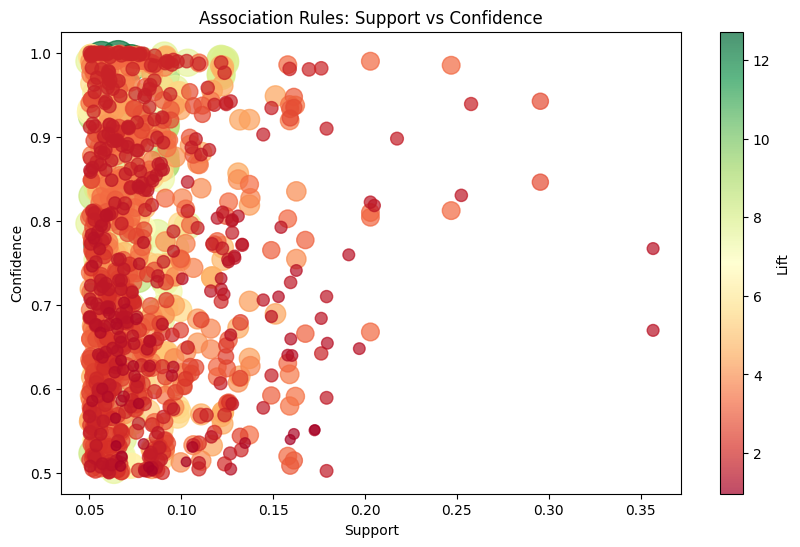

In [17]:
# APRIORI
target_skills = [
    'python', 'java', 'javascript', 'c++', 'c#', 'r', 'sql', 'php', 'ruby', 'swift',
    'kotlin', 'go', 'scala', 'typescript', 'matlab', 'html', 'css',
    'machine learning', 'deep learning', 'tensorflow', 'pytorch', 'keras',
    'pandas', 'numpy', 'scikit-learn', 'data analysis', 'data visualization',
    'statistics', 'nlp', 'computer vision', 'big data',
    'mysql', 'postgresql', 'mongodb', 'oracle', 'redis', 'elasticsearch',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'git', 'linux',
    'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring',
    'hadoop', 'spark', 'tableau', 'power bi', 'excel',
    'communication', 'leadership', 'teamwork', 'problem solving',
    'critical thinking', 'project management', 'agile', 'scrum'
]

# Extract skills
dataset_clean['Skills'] = dataset_clean['Resume_Cleaned'].apply(
    lambda x:  [s for s in target_skills if re.search(rf'\b{re. escape(s)}\b', str(x).lower())])
dataset_clean['Skills_Count'] = dataset_clean['Skills'].apply(len)

# Top 10 skills
skill_counts = Counter([s for skills in dataset_clean['Skills'] for s in skills])
print("Top 10 Skills:")
for skill, count in skill_counts.most_common(10):
    print(f"  {skill}: {count}")

# Apriori
transactions = dataset_clean[dataset_clean['Skills_Count'] > 0]['Skills'].tolist()
te = TransactionEncoder()
df_encoded = pd.DataFrame(te. fit_transform(transactions), columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True, max_len=3)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5).sort_values('lift', ascending=False)

print(f"\nFrequent itemsets:  {len(frequent_itemsets)}")
print(f"Association Rules: {len(rules)}\n")

rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]. head(15).copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
print(rules_display. round(4).to_string(index=False))

# Vẽ biểu đồ scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='RdYlGn', s=rules['lift']*50, alpha=0.7)
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.show()

V. MODEL EVALUATION    

In [18]:
# SO SÁNH CÁC CHỈ SỐ EVALUATION
# Tạo bảng so sánh các chỉ số
def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# Tính metrics cho 3 model
metrics_knn = calculate_metrics(y_test, y_pred_knn, f'KNN (k={best_k})')
metrics_nb = calculate_metrics(y_test, y_pred_nb, 'Naive Bayes')
metrics_svm = calculate_metrics(y_test, y_pred_svm, 'SVM (LinearSVC)')

# Tạo DataFrame
metrics_df = pd.DataFrame([metrics_knn, metrics_nb, metrics_svm])
print("BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH")
print(metrics_df.round(4).to_string(index=False))

BẢNG SO SÁNH CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH
          Model  Accuracy  Precision  Recall  F1-Score
     KNN (k=15)    0.9867     0.9861  0.9867    0.9862
    Naive Bayes    0.9690     0.9656  0.9690    0.9646
SVM (LinearSVC)    0.9971     0.9972  0.9971    0.9970


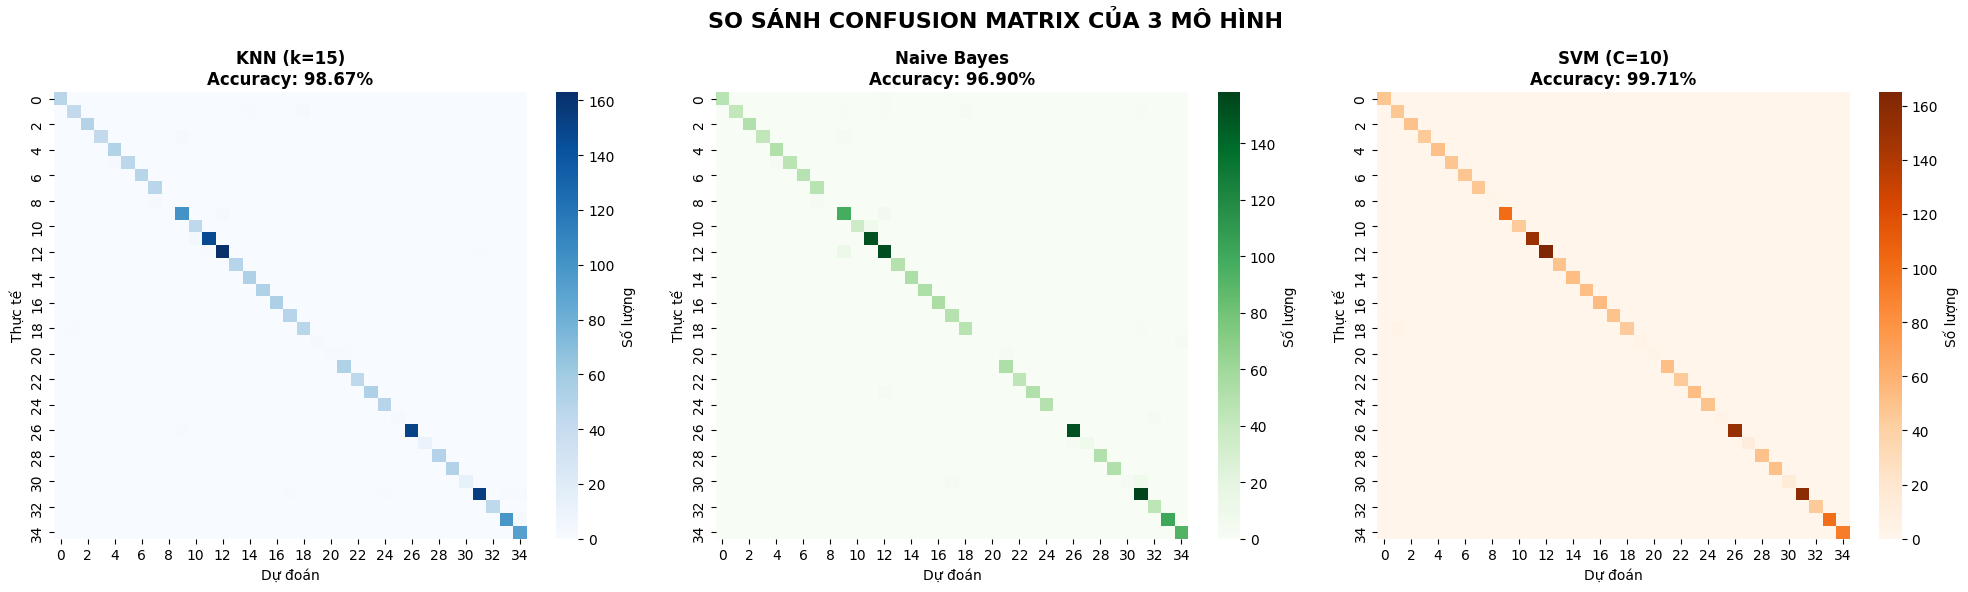

In [19]:
# TÍNH CONFUSION MATRIX CHO 3 MÔ HÌNH
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt. subplots(1, 3, figsize=(20, 6))

# Heatmap cho KNN
sns. heatmap(cm_knn, annot=False, cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Số lượng'})
axes[0].set_title(f'KNN (k={best_k})\nAccuracy: {best_acc_knn:.2%}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dự đoán')
axes[0]. set_ylabel('Thực tế')

# Heatmap cho Naive Bayes
sns. heatmap(cm_nb, annot=False, cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'Số lượng'})
axes[1].set_title(f'Naive Bayes\nAccuracy: {acc_nb:.2%}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dự đoán')
axes[1].set_ylabel('Thực tế')

# Heatmap cho SVM
sns.heatmap(cm_svm, annot=False, cmap='Oranges', ax=axes[2],
            cbar_kws={'label': 'Số lượng'})
axes[2].set_title(f'SVM (C={grid.best_params_["C"]})\nAccuracy: {acc_svm:.2%}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Dự đoán')
axes[2].set_ylabel('Thực tế')

plt.suptitle('SO SÁNH CONFUSION MATRIX CỦA 3 MÔ HÌNH', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Nhận xét:

Các giá trị lớn tập trung chủ yếu trên đường chéo chính, cho thấy các mô hình dự đoán chính xác phần lớn CV

Một số lỗi xuất hiện ở các ô ngoài đường chéo, nguyên nhân chủ yếu do các vai trò nghề nghiệp có kỹ năng tương đồng

In [20]:
# CLASSIFICATION REPORT CHO CẢ 3 MÔ HÌNH
print("CLASSIFICATION REPORT CHO CẢ 3 MÔ HÌNH")

# Danh sách các mô hình
models_info = [
    (f'KNN (k={best_k})', y_pred_knn),
    ('NAIVE BAYES', y_pred_nb),
    ('SVM (LinearSVC)', y_pred_svm)
]

for model_name, y_pred in models_info:
    print(f"{model_name}")
    print(classification_report(y_test, y_pred,
                               target_names=le_role.classes_,
                               zero_division=0))

CLASSIFICATION REPORT CHO CẢ 3 MÔ HÌNH
KNN (k=15)
                              precision    recall  f1-score   support

      AI Researcher/Engineer       1.00      1.00      1.00        48
             AR/VR Developer       0.98      0.91      0.95        47
        Blockchain Developer       1.00      1.00      1.00        50
            Business Analyst       1.00      0.96      0.98        45
             Cloud Architect       0.96      1.00      0.98        51
              Cloud Engineer       1.00      0.96      0.98        48
              Content Writer       1.00      1.00      1.00        48
       Cybersecurity Analyst       0.96      1.00      0.98        47
    Cybersecurity Specialist       0.00      0.00      0.00         2
                Data Analyst       0.97      0.98      0.98       103
              Data Architect       0.92      1.00      0.96        45
               Data Engineer       0.99      0.97      0.98       151
              Data Scientist       0.99

In [21]:
# PHÂN TÍCH CÁC CASE BỊ PHÂN LOẠI SAI

print("PHÂN TÍCH CÁC CASE BỊ PHÂN LOẠI SAI")
# Tạo DataFrame kết quả
results_df = pd.DataFrame({
    'True_Role': y_test. reset_index(drop=True),
    'Pred_KNN': y_pred_knn,
    'Pred_NB': y_pred_nb,
    'Pred_SVM': y_pred_svm
})

# Chuyển label encoded về tên Role
results_df['True_Role_Name'] = le_role. inverse_transform(results_df['True_Role'])
results_df['Pred_KNN_Name'] = le_role. inverse_transform(results_df['Pred_KNN'])
results_df['Pred_NB_Name'] = le_role.inverse_transform(results_df['Pred_NB'])
results_df['Pred_SVM_Name'] = le_role.inverse_transform(results_df['Pred_SVM'])

# Xác định các case bị phân loại sai
results_df['Wrong_KNN'] = results_df['True_Role'] != results_df['Pred_KNN']
results_df['Wrong_NB'] = results_df['True_Role'] != results_df['Pred_NB']
results_df['Wrong_SVM'] = results_df['True_Role'] != results_df['Pred_SVM']

# Thống kê số lượng case phân loại sai
print("\n THỐNG KÊ SỐ LƯỢNG PHÂN LOẠI SAI:")
print(f"KNN (k={best_k}):   {results_df['Wrong_KNN'].sum():>3} / {len(results_df)} mẫu sai")
print(f"Naive Bayes:       {results_df['Wrong_NB']. sum():>3} / {len(results_df)} mẫu sai")
print(f"SVM:               {results_df['Wrong_SVM'].sum():>3} / {len(results_df)} mẫu sai")

# Chi tiết các case sai
models_info = [
    (f'KNN (k={best_k})', 'Wrong_KNN', 'Pred_KNN_Name'),
    ('NAIVE BAYES', 'Wrong_NB', 'Pred_NB_Name'),
    ('SVM', 'Wrong_SVM', 'Pred_SVM_Name')
]
print(" ")

for model_name, wrong_col, pred_col in models_info:
    print(" ")
    print(f" CÁC CASE BỊ PHÂN LOẠI SAI - {model_name}")
    wrong_cases = results_df[results_df[wrong_col]]

    if len(wrong_cases) == 0:
        print(" Không có case nào bị phân loại sai!")
    else:
        for i, (idx, row) in enumerate(wrong_cases.iterrows(), 1):
            print(f"\n Case {i}:")
            print(f"   - Thực tế: {row['True_Role_Name']}")
            print(f"   - Dự đoán: {row[pred_col]}")

PHÂN TÍCH CÁC CASE BỊ PHÂN LOẠI SAI

 THỐNG KÊ SỐ LƯỢNG PHÂN LOẠI SAI:
KNN (k=15):    27 / 2035 mẫu sai
Naive Bayes:        63 / 2035 mẫu sai
SVM:                 6 / 2035 mẫu sai
 
 
 CÁC CASE BỊ PHÂN LOẠI SAI - KNN (k=15)

 Case 1:
   - Thực tế: Cybersecurity Specialist
   - Dự đoán: Cybersecurity Analyst

 Case 2:
   - Thực tế: UI Engineer
   - Dự đoán: UI/UX Designer

 Case 3:
   - Thực tế: Software Engineer
   - Dự đoán: UI Engineer

 Case 4:
   - Thực tế: AR/VR Developer
   - Dự đoán: Game Developer

 Case 5:
   - Thực tế: Business Analyst
   - Dự đoán: Data Analyst

 Case 6:
   - Thực tế: AR/VR Developer
   - Dự đoán: Devops Engineer

 Case 7:
   - Thực tế: HR Specialist
   - Dự đoán: Human Resources Specialist

 Case 8:
   - Thực tế: Data Analyst
   - Dự đoán: Data Scientist

 Case 9:
   - Thực tế: Software Engineer
   - Dự đoán: UI/UX Designer

 Case 10:
   - Thực tế: Data Engineer
   - Dự đoán: Data Architect

 Case 11:
   - Thực tế: Cybersecurity Specialist
   - Dự đoán: Cyb

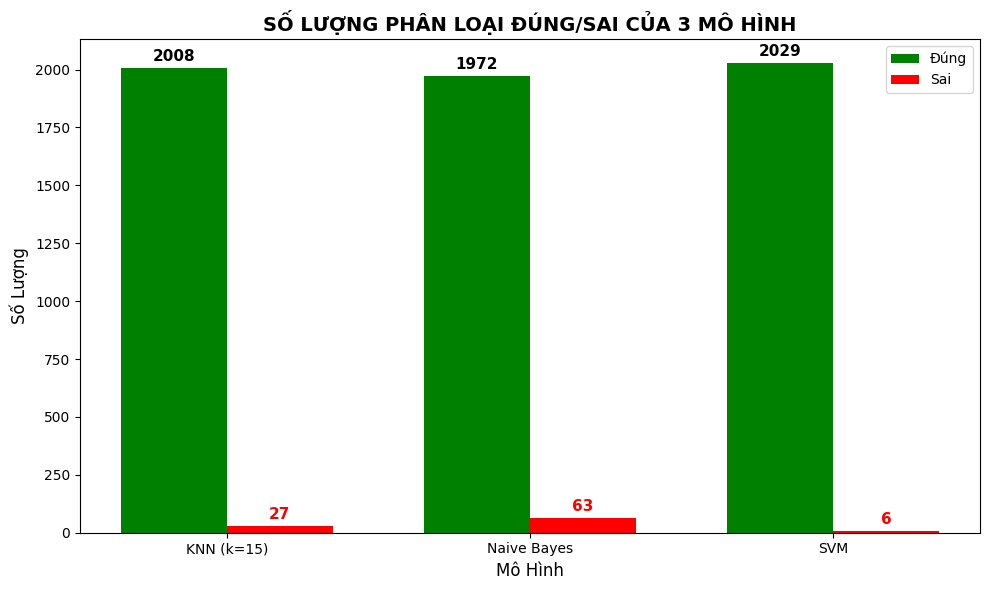

In [22]:
# BIỂU ĐỒ SỐ LƯỢNG PHÂN LOẠI ĐÚNG/SAI
models = [f'KNN (k={best_k})', 'Naive Bayes', 'SVM']
wrong_counts = [
    results_df['Wrong_KNN']. sum(),
    results_df['Wrong_NB'].sum(),
    results_df['Wrong_SVM'].sum()
]
correct_counts = [len(results_df) - w for w in wrong_counts]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, correct_counts, width, label='Đúng', color='Green')
bars2 = ax.bar(x + width/2, wrong_counts, width, label='Sai', color='Red')

ax.set_xlabel('Mô Hình', fontsize=12)
ax.set_ylabel('Số Lượng', fontsize=12)
ax.set_title('SỐ LƯỢNG PHÂN LOẠI ĐÚNG/SAI CỦA 3 MÔ HÌNH', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Thêm số liệu trên cột
for bar in bars1:
    height = bar. get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar. get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar. get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.show()